**Author:** Hsin-Ting Chen

In [1]:
import pandas as pd
import numpy as np

data=pd.read_csv("data_targets.csv")
data['CS-SINS Label'] = np.where(data['CS-SINS Score'] < 0.35, "Low", "High")

In [2]:
import pandas as pd
Data=pd.read_csv("ph6_lilly.csv").reset_index(drop=True)
Index=[
'patch_hyd',
'patch_hyd_1',
'patch_hyd_n',
'patch_hyd_%',
'patch_pos',
'patch_pos_1',
'patch_pos_n',
'patch_pos_%',
'patch_neg',
'patch_neg_1',
'patch_neg_n',
'patch_neg_%',
'patch_ion',
'patch_ion_1',
'patch_ion_n',
'patch_ion_%',
'patch_cdr_hyd',
'patch_cdr_hyd_1',
'patch_cdr_hyd_n',
'patch_cdr_pos',
'patch_cdr_pos_1',
'patch_cdr_pos_n',
'patch_cdr_neg',
'patch_cdr_neg_1',
'patch_cdr_neg_n',
'patch_cdr_ion',
'patch_cdr_ion_1',
'patch_cdr_ion_n',
'ens_dipole',
'pI_3D',
'asa_vdw',
'asa_hyd',
'asa_hph',
'app_charge','dipole_moment','hyd_moment',
'zdipole',
'zquadrupole',
'pI_seq',
]

Lilly=Data.loc[:,Index]

In [3]:
X=Lilly
y=data.iloc[:,-1]

In [4]:
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import *
parameters = {'max_depth':[3,4,5] , 'min_impurity_decrease':[0.02,0.025],"min_samples_leaf":[3,4,5],"random_state":[0,1,2,3,4,5]}
clf = GridSearchCV(DTC(), parameters,return_train_score=True,cv=LeaveOneOut())
clf.fit(X,  y)
print(clf.best_params_)
print(clf.best_score_)

{'max_depth': 3, 'min_impurity_decrease': 0.025, 'min_samples_leaf': 3, 'random_state': 3}
0.7684210526315789


0.8842105263157894
0.8843085106382979
0.875
0.8936170212765957
0.8842105263157894


[Text(0.3333333333333333, 0.875, 'pI_3D <= 7.672\ngini = 0.5\nsamples = 95\nvalue = [47, 48]\nclass = Low'),
 Text(0.16666666666666666, 0.625, 'gini = 0.236\nsamples = 44\nvalue = [38, 6]\nclass = High'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'asa_hyd <= 5731.567\ngini = 0.291\nsamples = 51\nvalue = [9, 42]\nclass = Low'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.201\nsamples = 44\nvalue = [5, 39]\nclass = Low'),
 Text(0.6666666666666666, 0.375, 'patch_neg_1 <= 55.0\ngini = 0.49\nsamples = 7\nvalue = [4, 3]\nclass = High'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]\nclass = High'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]\nclass = Low')]

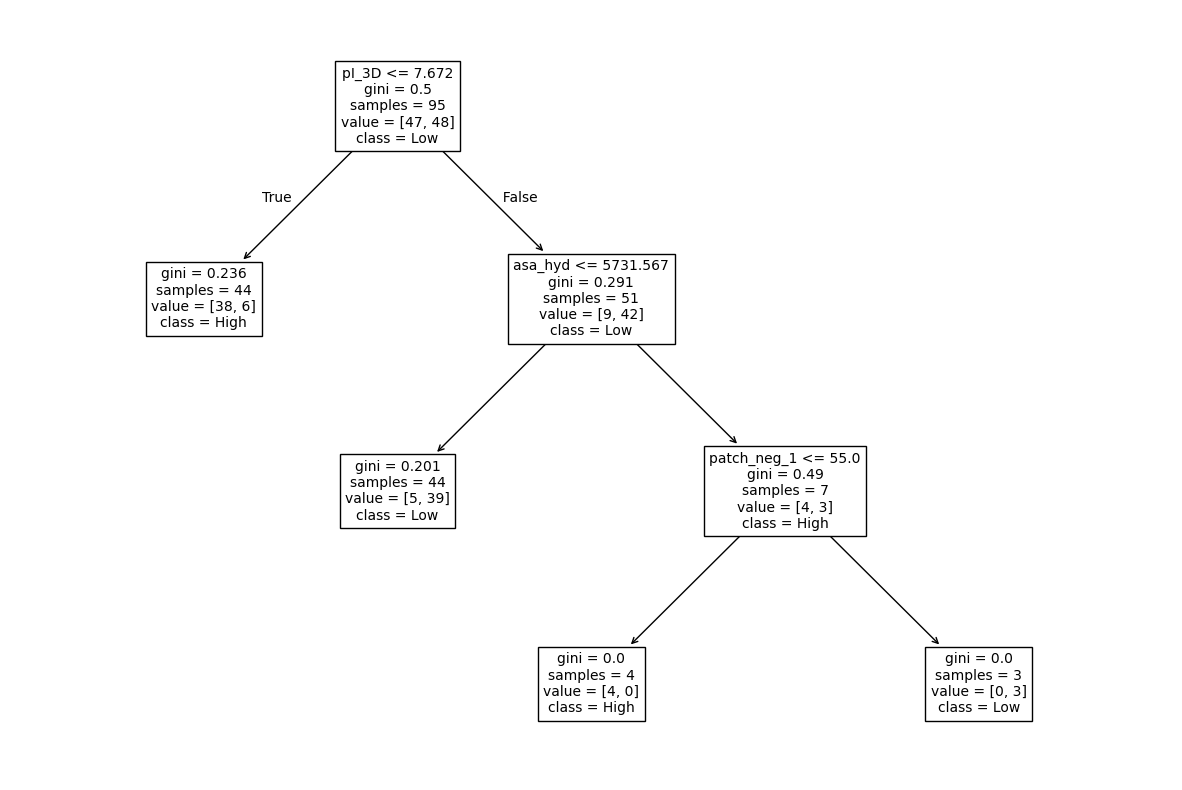

In [5]:
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt



#cs-sins 0.35
clf = tree.DecisionTreeClassifier(max_depth = 3, min_impurity_decrease=0.025,min_samples_leaf=3,random_state=3).fit(X, y)
ph5_predict = pd.DataFrame(clf.predict(X))

print(accuracy_score(ph5_predict, y))
print(balanced_accuracy_score(y,ph5_predict))
print(precision_score(y,ph5_predict.iloc[:,0],pos_label="High"))
print(recall_score(y,ph5_predict.iloc[:,0],pos_label="High"))
print(f1_score(y,ph5_predict.iloc[:,0],pos_label="High"))

plt.figure(figsize = (15,10))
plot_tree(clf, feature_names = X.columns,class_names=["High","Low"], fontsize = 10)